In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from tqdm.auto import tqdm
from scipy.integrate import solve_ivp as sp_solve_ivp

In [20]:
## Define system 
gamma = 50
def sigmoid(x,gamma=gamma):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2

def two_tank_system(t,x,u):
    x1, x2 = x
    p, v = u
    x1= np.maximum(x1,0)
    x2 = np.maximum(x2,0)
    dx1dt = c1_in(x1)*(1-v)*p-c1_out(x2)*np.sqrt(x1)
    dx2dt = c2_in(x2)*v*p +c1_out(x2)*np.sqrt(x1)-q2*np.sqrt(x2)
    return np.hstack([dx1dt,dx2dt])


p_vals = np.linspace(0,1,101)
v_vals = np.linspace(0,1,101)
p_train = p_vals[10:-10:10]
v_train = v_vals[10:-10:10]

P_train, V_train = np.meshgrid(p_train,v_train)

In [21]:

Z1_true = np.zeros((len(p_vals),len(v_vals)))
Z2_true = np.zeros((len(p_vals),len(v_vals)))

for i, pi in enumerate(tqdm(p_vals)):
    for j, vj in enumerate(v_vals):
        t_max = 1000
        x0 = [0.5,0.5]
        u = np.array([pi,vj])
        sol = sp_solve_ivp(
            two_tank_system,
            t_span = [0,t_max],
            y0 = np.array(x0),
            t_eval= np.linspace(0,t_max, 501),
            args =(u,)
        )
        x1, x2 = sol.y[:,-1]
        Z1_true[i,j] = x1
        Z2_true[i,j] = x2

  0%|          | 0/101 [00:00<?, ?it/s]

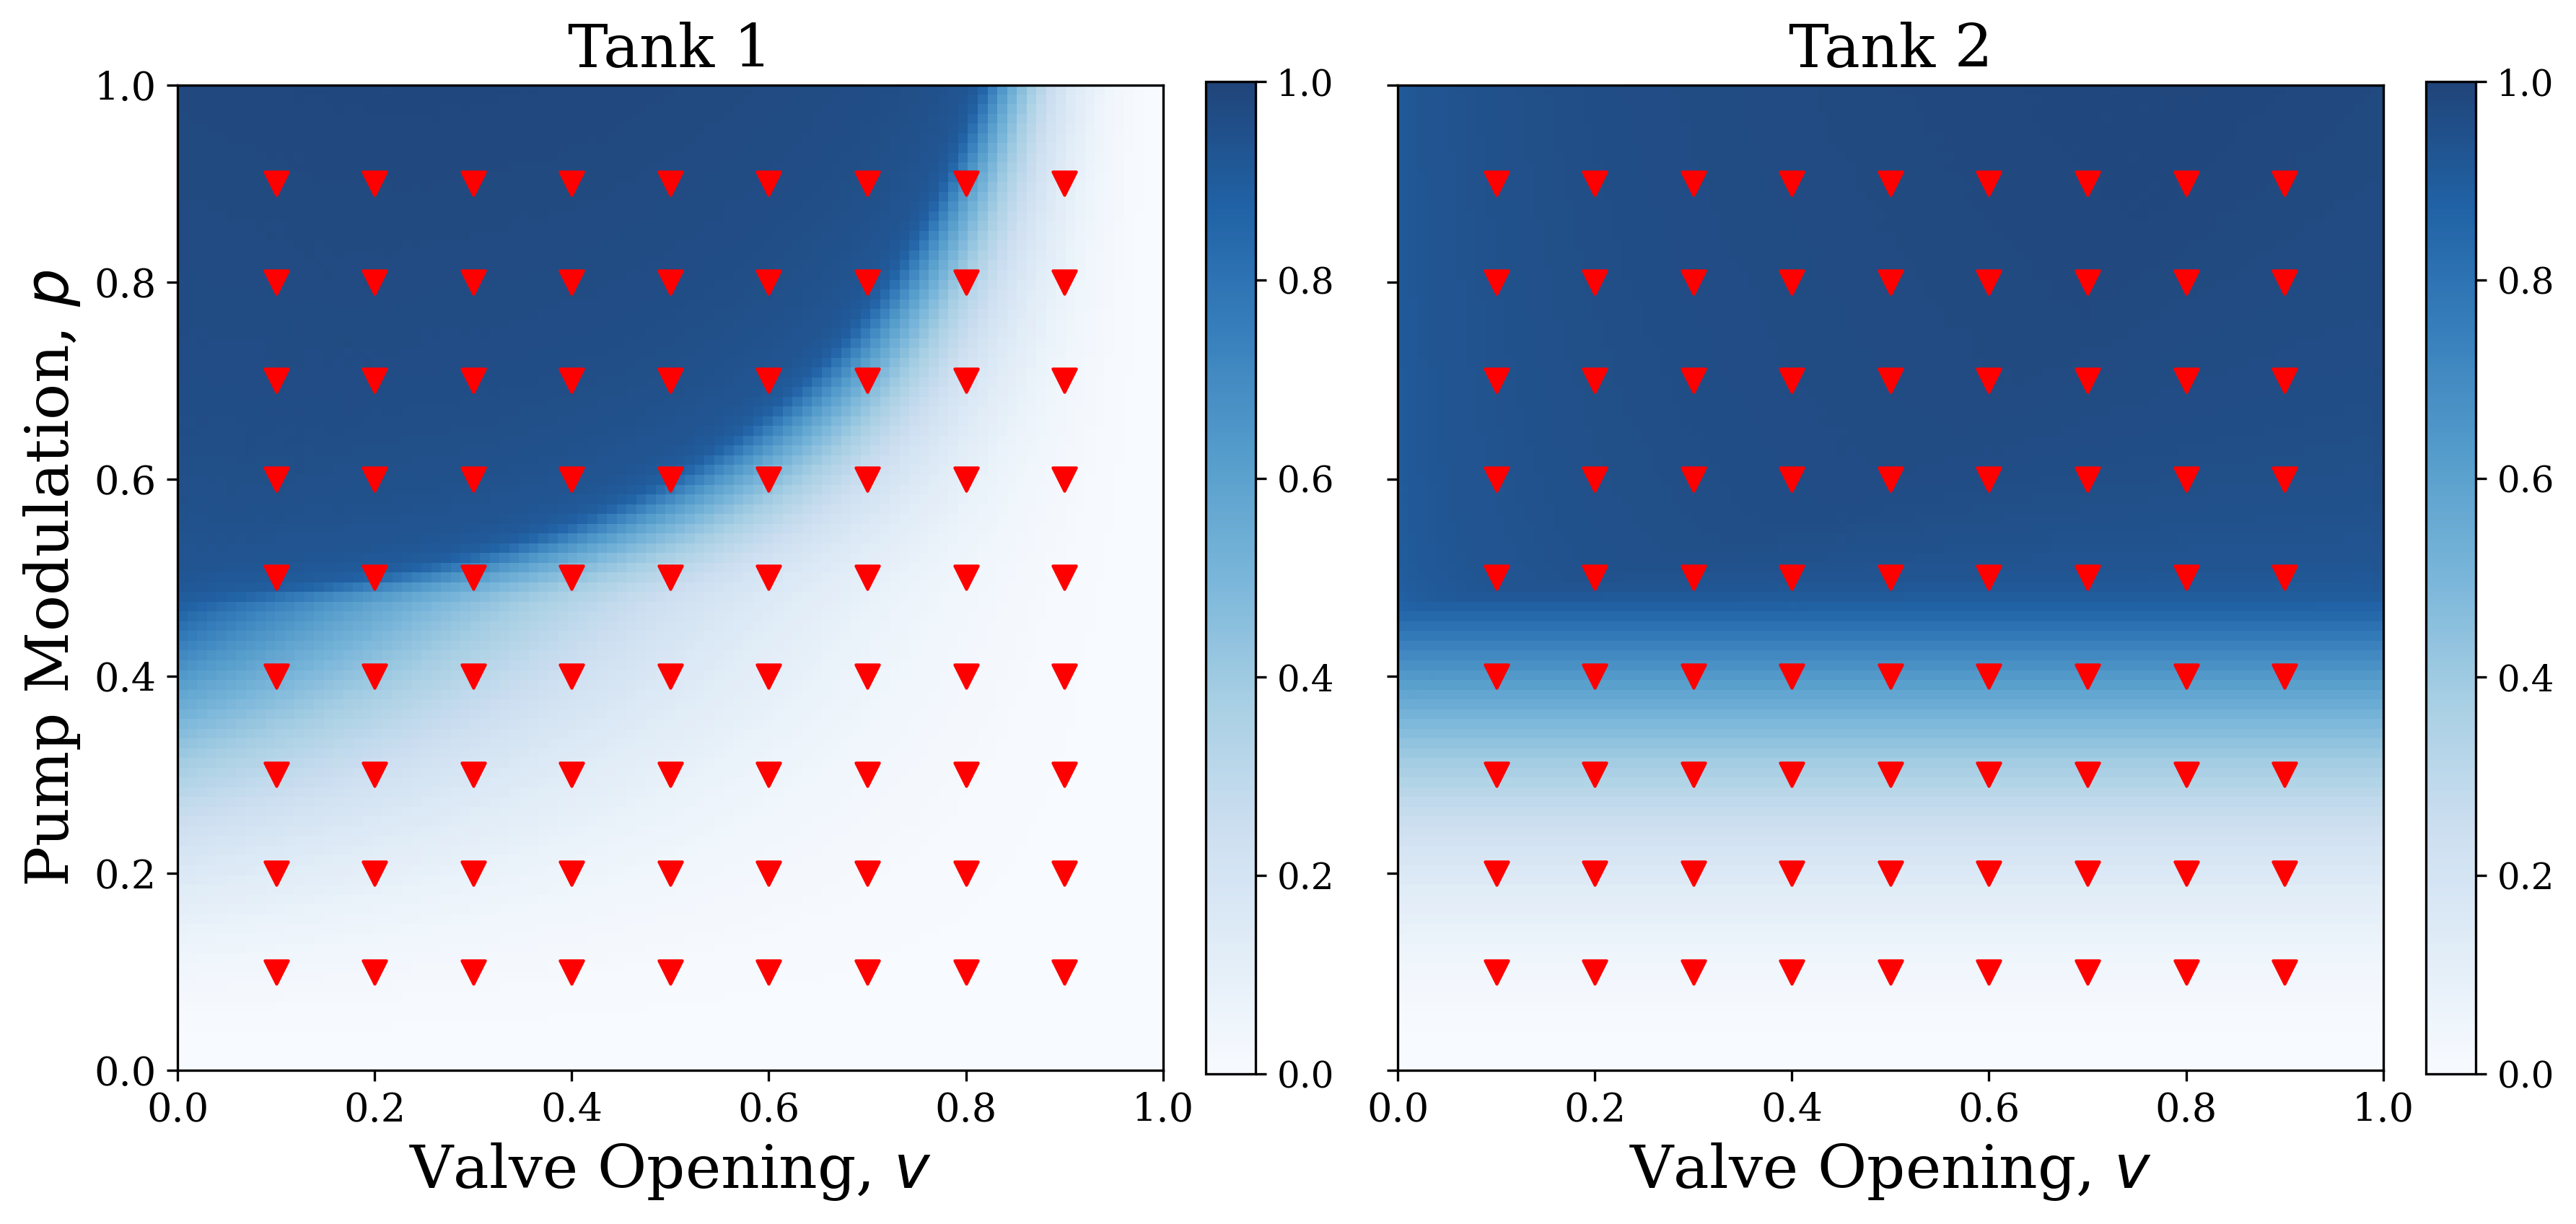

In [ ]:
cmap='Blues'
# cmap='magma'
alpha=0.9
trial_color = 'red'
trial_edge_color = 'red'
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,6),sharey=True,dpi=300)
im1 = ax1.imshow(Z1_true,extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],origin='lower',cmap=cmap,vmin=0,vmax=1,alpha=alpha)
cbar1 = fig.colorbar(im1,ax=ax1,fraction=0.046,pad=0.04)


ax1.scatter(V_train, P_train,marker='v',facecolor=trial_color,edgecolors=trial_edge_color,lw=1,s=60,zorder=1)
# ax1.scatter(V_train2, P_train2,marker='o',facecolor='black',edgecolors='black',lw=1,s=10,zorder=2)
ax1.set_ylabel(r"Pump Modulation, $p$",fontsize=20)
ax1.set_xlabel(r"Valve Opening, $v$",fontsize=20)
ax1.set_title("Tank 1",fontsize=20)
ax1.grid(False)

im2 = ax2.imshow(Z2_true,extent=[v_vals[0],v_vals[-1],p_vals[0],p_vals[-1]],origin='lower',cmap=cmap,vmin=0,vmax=1,alpha=alpha)
cbar2 = fig.colorbar(im2,ax=ax2,fraction=0.046,pad=0.04)
ax2.scatter(V_train, P_train,marker='v',facecolor=trial_color,edgecolors=trial_edge_color,s=60,lw=1,zorder=1)
# ax2.scatter(V_train2, P_train2,marker='o',facecolor='black',edgecolors='black',s=10,lw=1,zorder=2)
ax2.set_xlabel(r"Valve Opening, $v$",fontsize=20)
ax2.set_title("Tank 2",fontsize=20)
ax2.grid(False)

ax1.tick_params(axis='both', which='major',labelsize=13)
ax2.tick_params(axis='both', which='major',labelsize=13)

cbar1.ax.tick_params(labelsize=12) 
cbar2.ax.tick_params(labelsize=12) 
# plt.suptitle(rf"",size=25)
plt.tight_layout()
plt.savefig("mixing-tanks-trials.png")
plt.show()

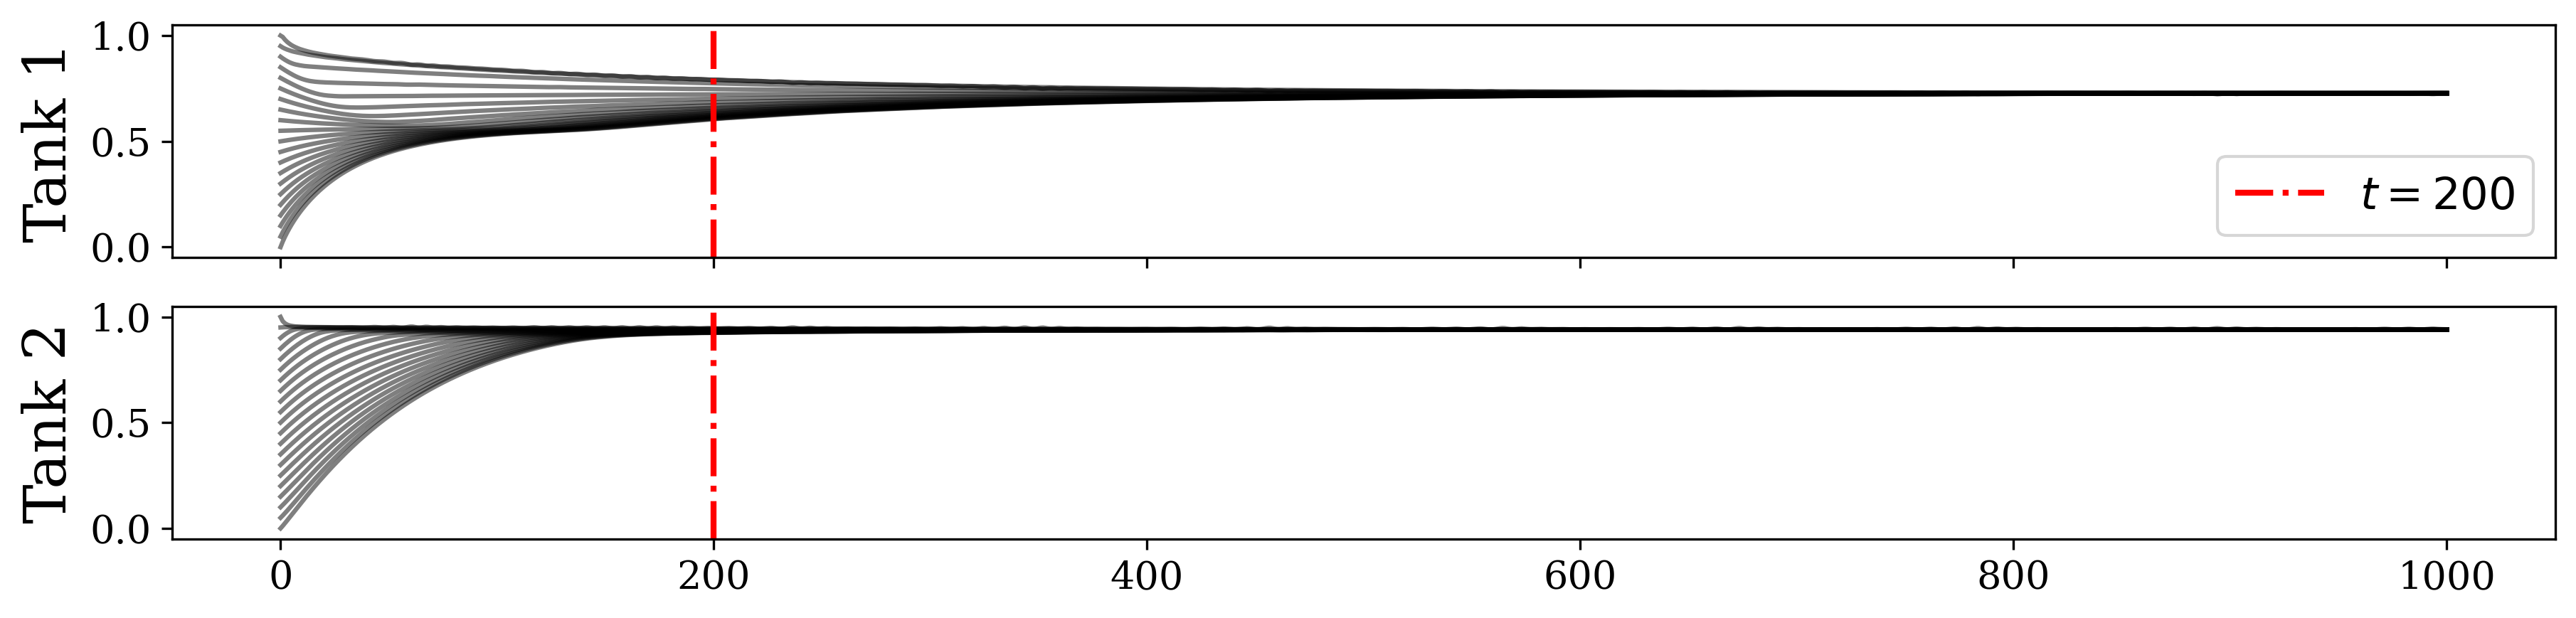

In [ ]:
x0s = np.linspace(0,1,21)

t_max = 1000
n_colloc = 1001
pi = 0.5
vi = 0.25
u = np.array([pi,vi])
trajectories = []
for x0 in zip(x0s, x0s):
    u = np.array([pi,vi])
    sol = sp_solve_ivp(
        two_tank_system,
        t_span = [0,t_max],
        y0 = np.array(x0),
        t_eval= np.linspace(0,t_max, n_colloc),
        args =(u,)
    )
    trajectories.append(
        (x0, sol.y)
    )

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(12,3),sharex=True,dpi=300)
for x0, y in trajectories:
    ax1.plot(sol.t, y[0,:],c='black',alpha=0.5)
    ax2.plot(sol.t, y[1,:],c='black',alpha=0.5)
# ax1.axvline(25, linestyle='--',c='red', lw=2,label=r"$t=25$")
# ax2.axvline(25,linestyle='--',c='red', lw=2)
# ax1.axvline(50, linestyle='-.',c='red', lw=2,label=r"$t=50$")
# ax2.axvline(50,linestyle='-.',c='red', lw=2)
ax1.axvline(200, linestyle='-.',c='red', lw=2,label=r"$t=200$")
ax2.axvline(200,linestyle='-.',c='red', lw=2)
ax1.set_ylabel("Tank 1",fontsize=20)
ax2.set_ylabel("Tank 2",fontsize=20)
ax1.legend(fontsize=15,loc='lower right')

ax1.tick_params(axis='both', which='major',labelsize=13)
ax2.tick_params(axis='both', which='major',labelsize=13)

plt.tight_layout()
plt.savefig("mixing-tanks-traj.png",bbox_inches='tight')
plt.show()